<a href="https://colab.research.google.com/github/SalvarezJ/Crib-Sentry/blob/main/notebooks/08_measure_cribhd_c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crib Sentry: CribHD-C Measurement
This is where I measure the system on CribHD-C. The system did not train on these 120 images. They show dolls on a mattress, and a blanket is on most dolls. My Blueprint kept these images apart to see how much worse the system is on them.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 4.1 MB/s eta 0:00:00
Mounted at /content/drive
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
GPU: Tesla T4
CribHD-C images: 120


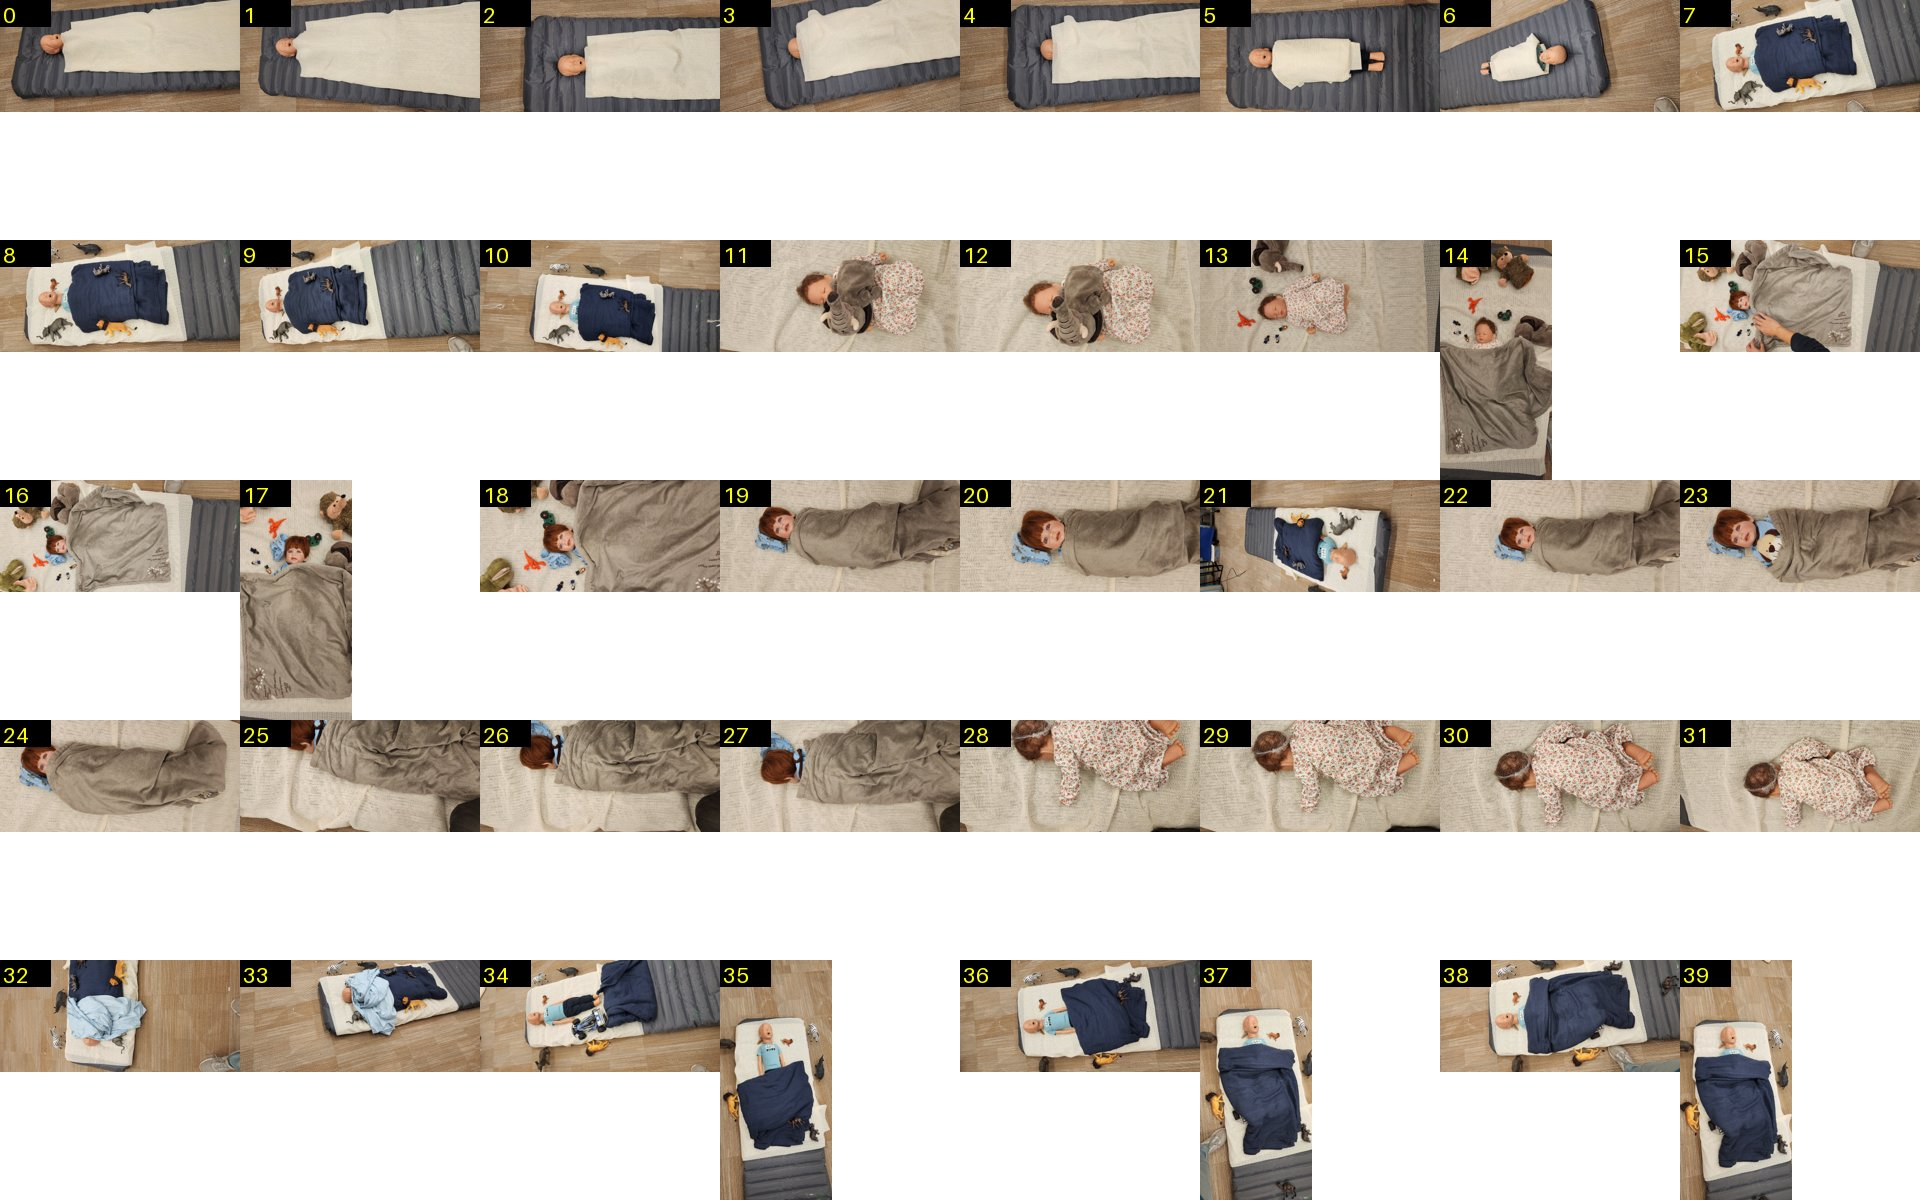

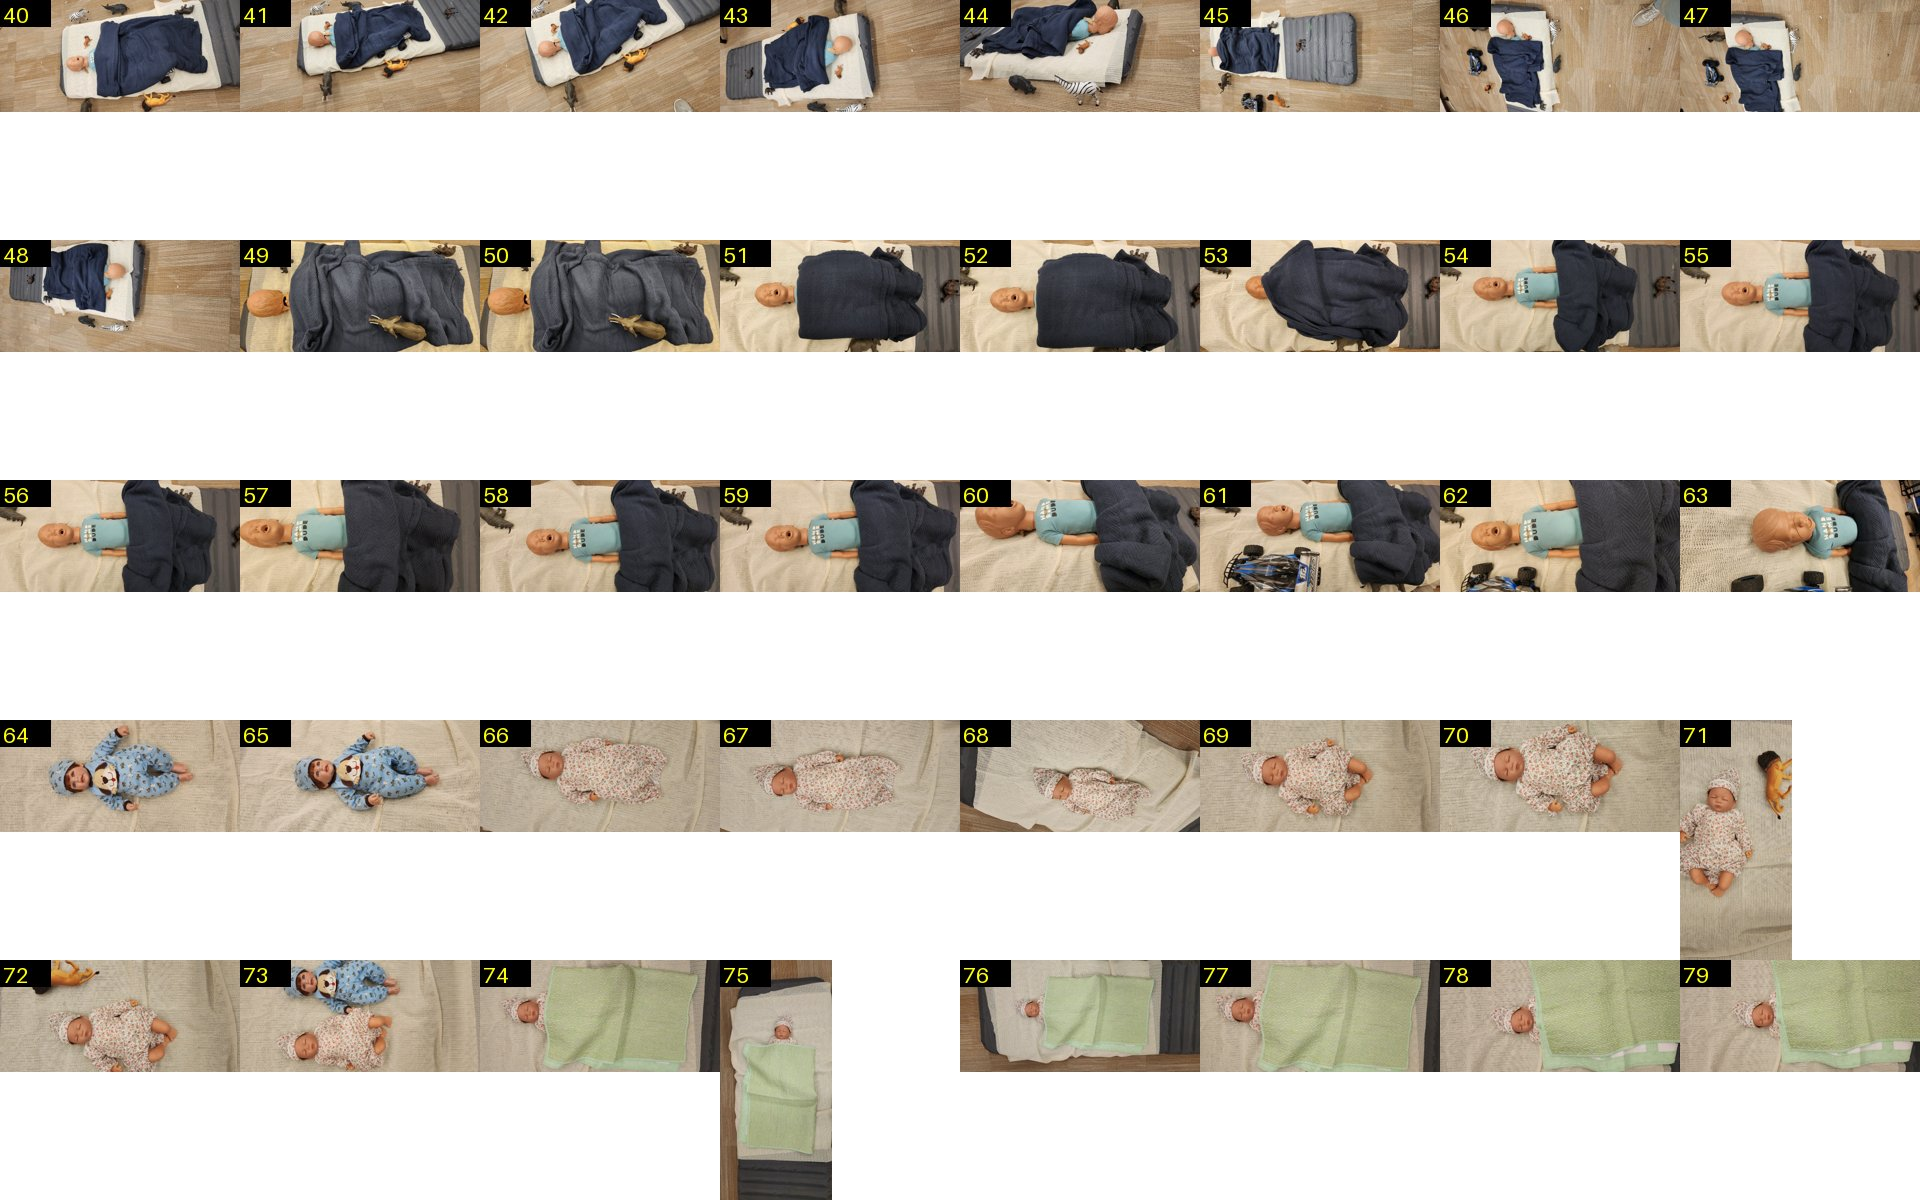

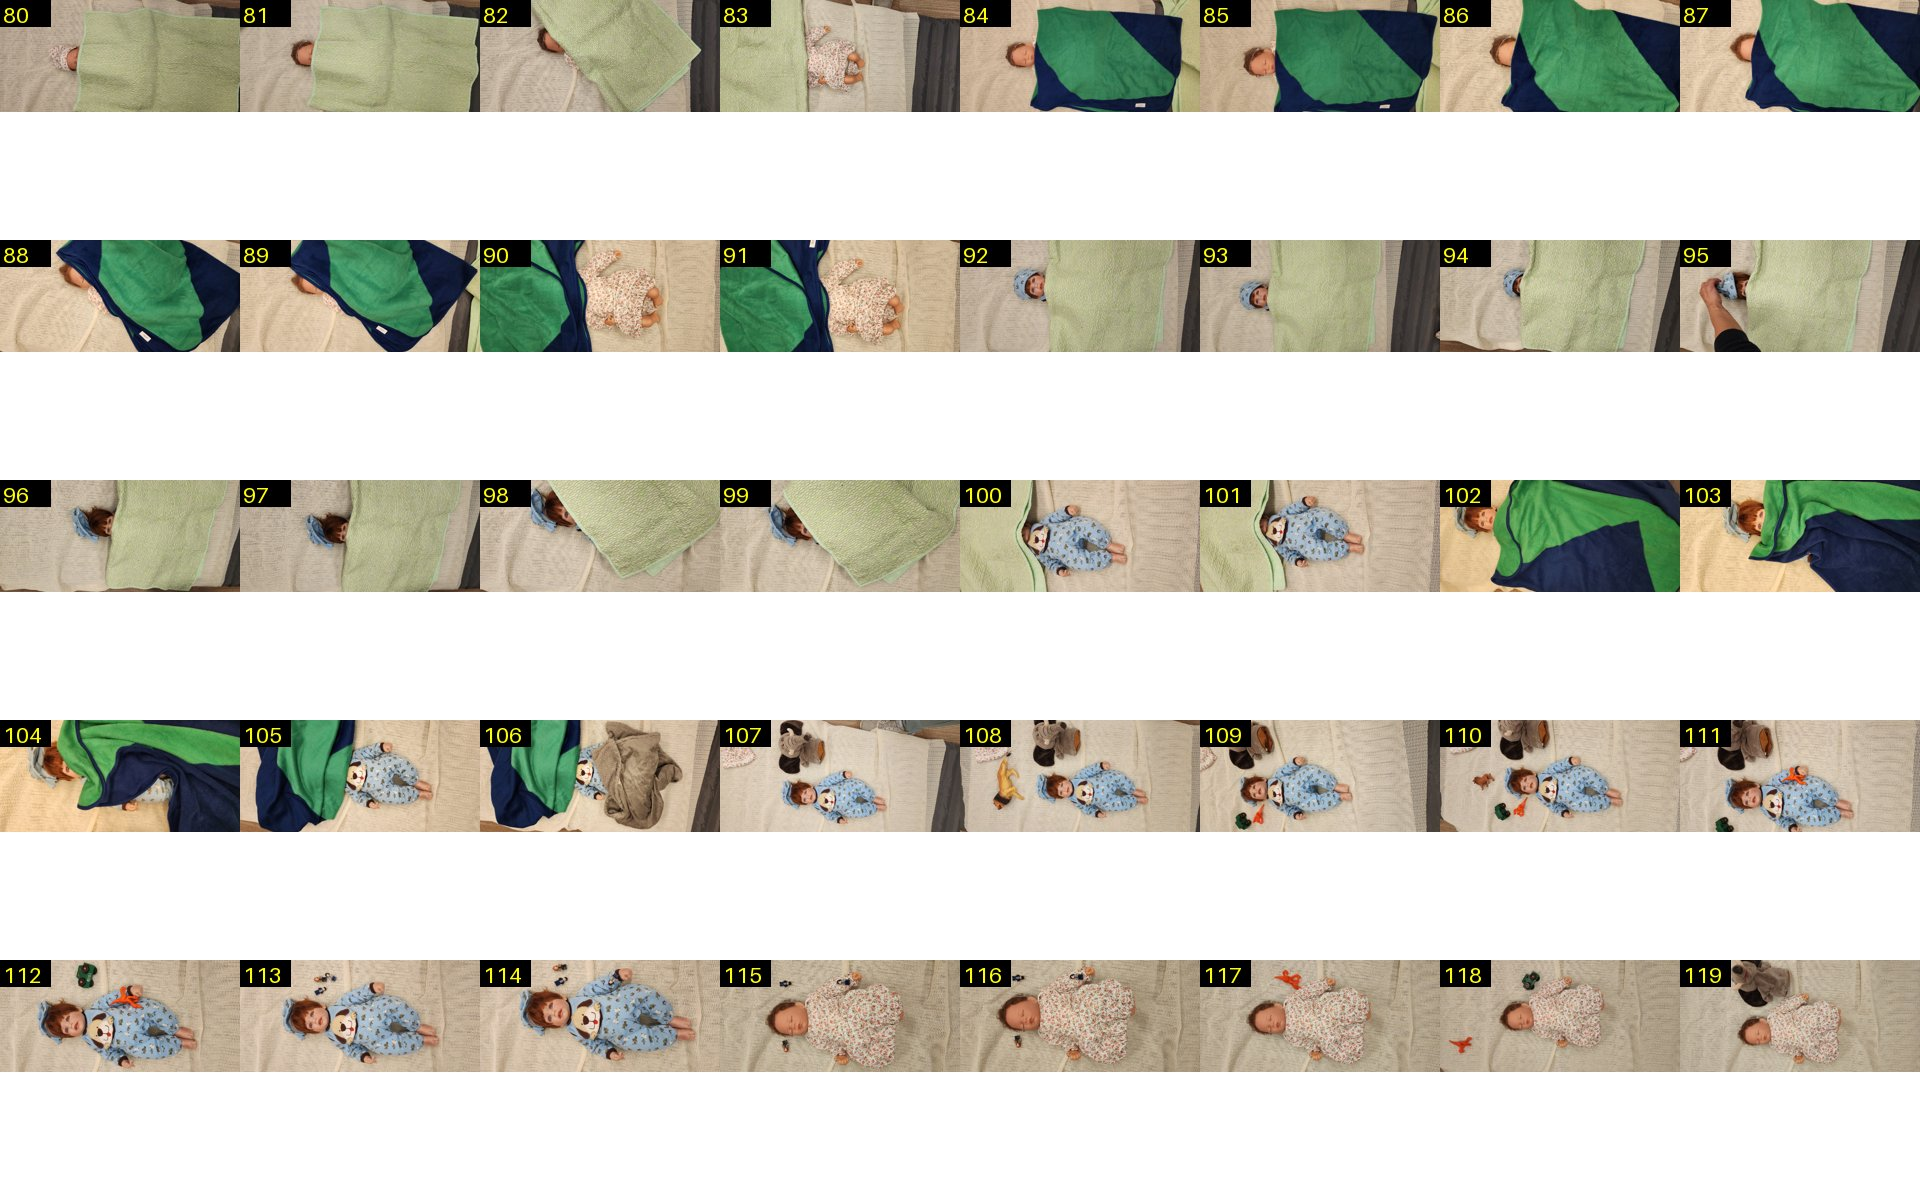

In [ ]:
!pip install -q ultralytics

from google.colab import drive
drive.mount('/content/drive')

import glob, os, time, torch
from ultralytics import YOLO
from PIL import Image as PILImage, ImageDraw, ImageFont
from IPython.display import Image, display

print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NONE')

base = '/content/drive/MyDrive/crib_sentry_v2'
!unzip -q -o {base}/CribHD.zip -d /content/
cribhd_c = sorted(glob.glob('/content/CribHD/CribHD-C/*'))
print('CribHD-C images:', len(cribhd_c))

font = ImageFont.load_default(size=22)
for start in range(0, 120, 40):
    page = PILImage.new('RGB', (8 * 240, 5 * 240), 'white')
    d = ImageDraw.Draw(page)
    for k, p in enumerate(cribhd_c[start:start + 40]):
        im = PILImage.open(p).convert('RGB')
        im.thumbnail((240, 240))
        x, y = (k % 8) * 240, (k // 8) * 240
        page.paste(im, (x, y))
        d.rectangle([x, y, x + 50, y + 26], fill='black')
        d.text((x + 3, y + 1), str(start + k), fill='yellow', font=font)
    page.save(f'/content/c_{start}.jpg', quality=85)
    display(Image(filename=f'/content/c_{start}.jpg'))

## My tags
I tag each image before the system runs. The mattress is the crib. A cover that is flat below the doll is the sheet. A cover on the doll or next to the doll is a loose blanket. A toy on the mattress is a hazard.

In [3]:
# c = all clear, l = left the crib, n = not visible, h = hazard present
rows = [
    'hhhhhhhhhh',  # 0 to 9
    'hhhhhhhhhh',  # 10 to 19
    'hhhhhhhhcc',  # 20 to 29
    'cchhhhhhhh',  # 30 to 39
    'hhhhhhhhhh',  # 40 to 49
    'hhhhhhhhhh',  # 50 to 59
    'hhhhcccccc',  # 60 to 69
    'chhchhhhhh',  # 70 to 79
    'hhhhhhhhhh',  # 80 to 89
    'hhhhhhhhhh',  # 90 to 99
    'hhhhhhhhhh',  # 100 to 109
    'hhhhhhhhhh',  # 110 to 119
]

names = {'c': 'all clear', 'l': 'left the crib', 'n': 'not visible', 'h': 'hazard present'}
letters = ''.join(rows)
assert len(letters) == 120 and set(letters) <= set('clnh'), 'Each row needs 10 letters from c, l, n, h'
tags = [names[x] for x in letters]

for name in names.values():
    print(name, tags.count(name))

all clear 12
left the crib 0
not visible 0
hazard present 108


## Measure the two systems
The alert rules are the same as in notebook 04. I also count the images where each system finds a crib and where it finds a child.

In [4]:
old_child_crib = YOLO(f'{base}/child_crib/weights/best.pt')
new_child = YOLO(f'{base}/child-2/weights/best.pt')
new_crib = YOLO(f'{base}/crib/weights/best.pt')
hazards = YOLO(f'{base}/hazards/weights/best.pt')

def fraction_inside(inner, outer):
    x1 = max(inner[0], outer[0]); y1 = max(inner[1], outer[1])
    x2 = min(inner[2], outer[2]); y2 = min(inner[3], outer[3])
    if x2 <= x1 or y2 <= y1:
        return 0.0
    overlap = (x2 - x1) * (y2 - y1)
    inner_area = (inner[2] - inner[0]) * (inner[3] - inner[1])
    return overlap / inner_area

def get_facts(path, child_model, crib_model):
    results = [child_model(path, verbose=False)[0]]
    if crib_model is not child_model:
        results.append(crib_model(path, verbose=False)[0])
    children = []; crib = None; best_conf = 0
    for r in results:
        for box in r.boxes:
            name = r.names[int(box.cls[0])].lower()
            corners = box.xyxy[0].tolist()
            conf = float(box.conf[0])
            if name == 'child':
                children.append(corners)
            elif name == 'crib' and conf > best_conf:
                crib = corners; best_conf = conf
    hazard_list = []
    for box in hazards(path, verbose=False)[0].boxes:
        hazard_list.append((hazards.names[int(box.cls[0])], box.xyxy[0].tolist()))
    return children, crib, hazard_list

def decide(children, crib, hazard_list):
    if crib is None:
        return 'not visible'
    left_crib = False
    for child in children:
        if fraction_inside(child, crib) <= 0.5:
            left_crib = True
    hazard_present = False
    for name, box in hazard_list:
        if fraction_inside(box, crib) > 0.5:
            hazard_present = True
    if left_crib: return 'left the crib'
    if hazard_present: return 'hazard present'
    if len(children) == 0: return 'not visible'
    return 'all clear'

for title, child_model, crib_model in [('Old system', old_child_crib, old_child_crib),
                                       ('New system', new_child, new_crib)]:
    get_facts(cribhd_c[0], child_model, crib_model)   # the first call loads the models on the GPU
    alerts = []; child_found = 0; crib_found = 0
    start = time.time()
    for path in cribhd_c:
        children, crib, hazard_list = get_facts(path, child_model, crib_model)
        alerts.append(decide(children, crib, hazard_list))
        child_found += len(children) > 0
        crib_found += crib is not None
    seconds = (time.time() - start) / 120

    right = sum(a == t for a, t in zip(alerts, tags))
    print(title)
    print('  correct:', right, 'of 120 =', round(100 * right / 120, 1), '% |', round(seconds, 3), 'seconds for each image')
    print('  crib found in', crib_found, 'of 120 | child found in', child_found, 'of 120')
    for tag in ['all clear', 'hazard present']:
        given = [a for a, t in zip(alerts, tags) if t == tag]
        print('  my tag', tag, '->', {a: given.count(a) for a in sorted(set(given))})
    print('  wrong images:', [i for i in range(120) if alerts[i] != tags[i]])
    print()

Old system
  correct: 20 of 120 = 16.7 % | 0.229 seconds for each image
  crib found in 22 of 120 | child found in 102 of 120
  my tag all clear -> {'hazard present': 2, 'not visible': 10}
  my tag hazard present -> {'hazard present': 20, 'not visible': 88}
  wrong images: [6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 41, 42, 44, 46, 47, 49, 50, 53, 54, 56, 57, 58, 60, 61, 62, 64, 65, 66, 67, 68, 69, 70, 72, 73, 74, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119]

New system
  correct: 50 of 120 = 41.7 % | 0.325 seconds for each image
  crib found in 76 of 120 | child found in 104 of 120
  my tag all clear -> {'hazard present': 5, 'not visible': 7}
  my tag hazard present -> {'all clear': 7, 'hazard present': 50, 'left the crib': 13, 'not visible': 38}
  wrong image

## Results
- The old system gets 20 of 120 images correct (16.7%). The new system gets 50 of 120 correct (41.7%).
- The new system gets 70.8% on my 24 test images. Thus it is much worse on CribHD-C.
- The new system finds a child in 104 of 120 images, and a blanket is on most dolls. The blanket is not the main problem.
- The new system finds a crib in only 76 of 120 images. CribHD-C shows a mattress with no bars, and my Crib detector trained on cribs with bars.
- When the system finds no crib box, my rule gives "not visible".
- The new system uses 0.325 seconds for each image. My target was less than 1 second.